# Analise: fluxo negativo + tamanho dos HDF5 (LRG)

Duas perguntas:

1. **Fluxo negativo existe mesmo?** A normalizacao do notebook 07 produz valores em [-1, +1] — onde vem o negativo? E ruido real (subtracao de ceu) ou bug?
2. **Por que o padded (2.1 GB) e MENOR que o all (9 GB)?** Padding normalmente AUMENTA o arquivo. O que diminuiu?

Roda com:
```
conda activate thalita
jupyter lab
```

## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

# walk-up do project_root (procura config.py)
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'config.py').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from config import paths_for
from src.data import load_spectral_dataset, normalize_spectra

sns.set_theme(style='whitegrid')

paths = paths_for('LRG')
ALL_H5    = paths['spectra_h5'].with_name('LRGspectra_all.h5')
PADDED_H5 = paths['spectra_h5'].with_name('LRGspectra_padded.h5')

print(f'ALL    : {ALL_H5}')
print(f'PADDED : {PADDED_H5}')
print(f'\nTamanho em disco:')
print(f'  ALL    : {ALL_H5.stat().st_size / 1e9:.2f} GB')
print(f'  PADDED : {PADDED_H5.stat().st_size / 1e9:.2f} GB')

ALL    : /home/thalita/spec_z_ml/data/processed/LRG/LRGspectra_all.h5
PADDED : /home/thalita/spec_z_ml/data/processed/LRG/LRGspectra_padded.h5

Tamanho em disco:
  ALL    : 9.61 GB
  PADDED : 2.24 GB


## 2. Por que o padded e MENOR que o all?

Vou inspecionar a estrutura interna dos dois arquivos. Hipoteses:

1. **Menos espectros**: o padding e feito em cima do catalogo filtrado (sem zwarning, sem spec ruim) — pode ter caido amostra.
2. **Sem `ivar`**: o all guarda a variancia inversa de cada ponto. Se o padded so guarda flux, ja corta pela metade.
3. **Wave global vs per-espectro**: o all pode ter um array `wave` por espectro; o padded usa um unico `wave_global`.
4. **Compressao melhor**: gzip num bloco 2D grande comprime melhor que em milhares de blocos pequenos.

In [2]:
def inspect_h5(path, sample_groups=3):
    """Lista datasets, tipos, compressao, tamanho raw vs comprimido."""
    print(f'\n=== {path.name} ===')
    with h5py.File(path, 'r') as h5:
        # Lista grupos top-level
        print('Grupos top-level:', list(h5.keys()))
        
        # Mostra estrutura do catalog
        if 'catalog' in h5:
            cat = h5['catalog']
            print(f'\ncatalog/ tem {len(list(cat.keys()))} colunas, com {cat[list(cat.keys())[0]].shape[0]:,} linhas')
        
        # Spectra (formato individual)
        if 'spectra' in h5:
            n_spec = len(list(h5['spectra'].keys()))
            sample = list(h5['spectra'].keys())[:sample_groups]
            print(f'\nspectra/ tem {n_spec:,} grupos individuais')
            print(f'  exemplo: {sample}')
            for s in sample[:1]:
                grp = h5[f'spectra/{s}']
                print(f'  conteudo de {s}: {list(grp.keys())}')
                for k in grp.keys():
                    d = grp[k]
                    print(f'    {k:6} shape={d.shape}  dtype={d.dtype}  comp={d.compression}')
        
        # ml_dataset (formato achatado)
        if 'ml_dataset' in h5:
            print(f'\nml_dataset/:')
            for k in h5['ml_dataset'].keys():
                d = h5[f'ml_dataset/{k}']
                raw_gb = d.size * d.dtype.itemsize / 1e9
                print(f'  {k:8} shape={d.shape}  dtype={d.dtype}  comp={d.compression}  raw={raw_gb:.2f} GB')
        
        # Wave global?
        if 'wave_global' in h5:
            d = h5['wave_global']
            print(f'\nwave_global: shape={d.shape}  dtype={d.dtype}  (UM array de comprimento de onda compartilhado)')

inspect_h5(ALL_H5)
inspect_h5(PADDED_H5)


=== LRGspectra_all.h5 ===
Grupos top-level: ['catalog', 'spectra']

catalog/ tem 25 colunas, com 167,635 linhas

spectra/ tem 167,635 grupos individuais
  exemplo: ['LRG_000000', 'LRG_000001', 'LRG_000002']
  conteudo de LRG_000000: ['flux', 'ivar', 'wave']
    flux   shape=(4568,)  dtype=float32  comp=gzip
    ivar   shape=(4568,)  dtype=float32  comp=gzip
    wave   shape=(4568,)  dtype=float32  comp=gzip

=== LRGspectra_padded.h5 ===
Grupos top-level: ['catalog', 'ml_dataset', 'wave_global']

catalog/ tem 25 colunas, com 130,952 linhas

ml_dataset/:
  X_spec   shape=(130952, 4674)  dtype=float32  comp=gzip  raw=2.45 GB
  y        shape=(130952,)  dtype=float32  comp=None  raw=0.00 GB

wave_global: shape=(4674,)  dtype=float64  (UM array de comprimento de onda compartilhado)


In [3]:
# ============================================================
# CONTABILIDADE DETALHADA DO ESPACO RAW
# ============================================================
# Quero comparar tamanho RAW (sem compressao) vs em disco (com gzip).
# Hipotese: o all tem 3x mais dado raw (flux + ivar + wave_per_spec).

def raw_size_all(path):
    """Soma o raw de TODOS os spectra/LRG_XXXXXX/{flux, ivar, wave}."""
    total = {'flux': 0, 'ivar': 0, 'wave': 0}
    with h5py.File(path, 'r') as h5:
        spectra = h5['spectra']
        # Amostra os primeiros 1000 pra estimar (rapido)
        keys = list(spectra.keys())
        n_total = len(keys)
        sample = keys[:1000]
        for s in sample:
            for k in ('flux', 'ivar', 'wave'):
                d = spectra[f'{s}/{k}']
                total[k] += d.size * d.dtype.itemsize
        # Extrapola pra todos
        for k in total:
            total[k] = total[k] / len(sample) * n_total
    return total, n_total

totals_all, n_all = raw_size_all(ALL_H5)
print(f'LRGspectra_all.h5  ({n_all:,} espectros):')
for k, v in totals_all.items():
    print(f'  {k:6} : {v/1e9:.2f} GB raw')
print(f'  TOTAL  : {sum(totals_all.values())/1e9:.2f} GB raw')

with h5py.File(PADDED_H5, 'r') as h5:
    Xshape = h5['ml_dataset/X_spec'].shape
    n_pad = Xshape[0]
    n_wave = Xshape[1]
    raw_pad = n_pad * n_wave * 4  # float32 = 4 bytes

print(f'\nLRGspectra_padded.h5  ({n_pad:,} espectros):')
print(f'  X_spec : {raw_pad/1e9:.2f} GB raw  (shape {Xshape})')

print(f'\n--- RESUMO ---')
print(f'  espectros            : {n_all:,} -> {n_pad:,}  (perdeu {n_all - n_pad:,} = {(n_all-n_pad)/n_all*100:.1f}%)')
print(f'  raw total            : {sum(totals_all.values())/1e9:.2f} GB -> {raw_pad/1e9:.2f} GB')
print(f'  disco (com gzip)     : {ALL_H5.stat().st_size/1e9:.2f} GB -> {PADDED_H5.stat().st_size/1e9:.2f} GB')

LRGspectra_all.h5  (167,635 espectros):
  flux   : 3.07 GB raw
  ivar   : 3.07 GB raw
  wave   : 3.07 GB raw
  TOTAL  : 9.21 GB raw

LRGspectra_padded.h5  (130,952 espectros):
  X_spec : 2.45 GB raw  (shape (130952, 4674))

--- RESUMO ---
  espectros            : 167,635 -> 130,952  (perdeu 36,683 = 21.9%)
  raw total            : 9.21 GB -> 2.45 GB
  disco (com gzip)     : 9.61 GB -> 2.24 GB


### Conclusao parcial

Os 3 motivos pelos quais o padded e menor que o all:

1. **Filtragem de qualidade**: ~22% dos espectros foram removidos no notebook 02 (zwarning, spec ruim, etc.).
2. **`ivar` removida**: o all guarda flux + ivar (mesmo tamanho) — padded so tem flux.
3. **`wave` compartilhado**: o all tem um array de comprimento de onda POR espectro. O padded usa um unico `wave_global`.

Bonus: o gzip num **bloco 2D unico e grande** comprime melhor (overhead de metadata HDF5 diluido).

## 3. Fluxo negativo existe mesmo?

Vou olhar **diretamente no arquivo `all`** (antes de qualquer normalizacao ou padding) pra confirmar se o fluxo bruto tem mesmo valores negativos.

In [4]:
# ============================================================
# AMOSTRA 1000 ESPECTROS DO ARQUIVO `all` E CONFERE NEGATIVOS
# ============================================================
# Por que so 1000? O all tem 167k espectros com tamanhos diferentes. Iterar
# todos demora. 1000 da estatistica suficiente pra responder a pergunta.

n_sample = 1000

neg_counts = []      # quantos valores negativos por espectro
neg_fractions = []   # fracao negativa por espectro
min_values = []      # valor mais negativo de cada espectro
flux_examples = []   # guardo alguns pra plotar

with h5py.File(ALL_H5, 'r') as h5:
    keys = sorted(h5['spectra'].keys())[:n_sample]
    for k in keys:
        flux = h5[f'spectra/{k}/flux'][:]
        neg_counts.append(int((flux < 0).sum()))
        neg_fractions.append(float((flux < 0).mean()))
        min_values.append(float(flux.min()))
        if len(flux_examples) < 6:
            wave = h5[f'spectra/{k}/wave'][:]
            flux_examples.append((k, wave, flux))

neg_counts = np.array(neg_counts)
neg_fractions = np.array(neg_fractions)
min_values = np.array(min_values)

print(f'Amostra de {n_sample} espectros do all (sem normalizacao):')
print(f'  espectros com >= 1 valor negativo : {(neg_counts > 0).sum()} de {n_sample}')
print(f'  fracao media de valores negativos : {neg_fractions.mean()*100:.2f}%')
print(f'  fracao max                        : {neg_fractions.max()*100:.2f}%')
print(f'  valor mais negativo encontrado    : {min_values.min():.3e}')
print(f'  valor mais negativo medio         : {min_values.mean():.3e}')

Amostra de 1000 espectros do all (sem normalizacao):
  espectros com >= 1 valor negativo : 1000 de 1000
  fracao media de valores negativos : 20.53%
  fracao max                        : 37.94%
  valor mais negativo encontrado    : -5.177e-16
  valor mais negativo medio         : -1.168e-16


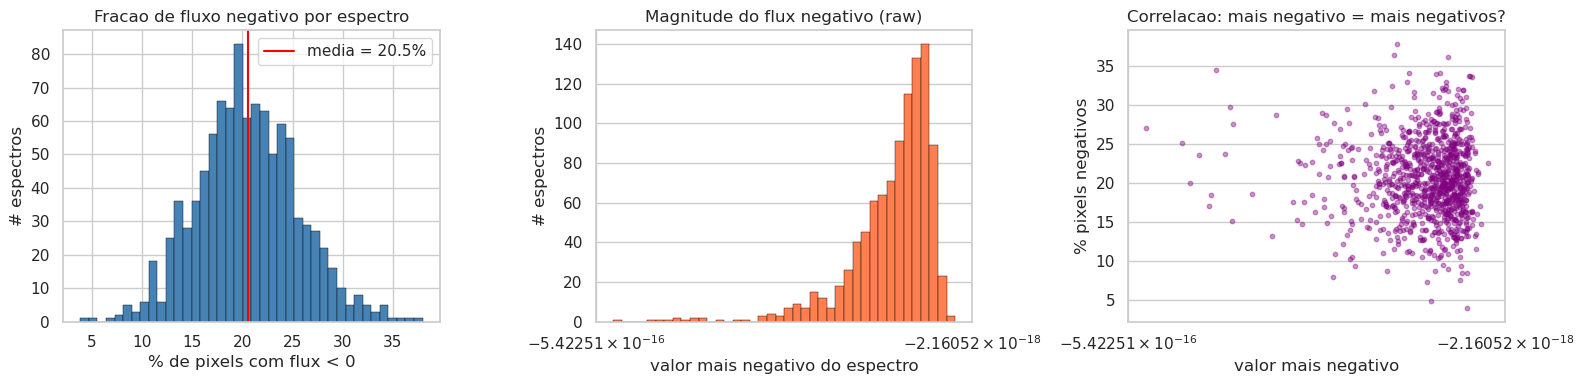

In [5]:
# ============================================================
# PLOT 1: distribuicoes das estatisticas de negativos
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(neg_fractions * 100, bins=40, color='steelblue', edgecolor='black', lw=0.3)
axes[0].set_xlabel('% de pixels com flux < 0')
axes[0].set_ylabel('# espectros')
axes[0].set_title('Fracao de fluxo negativo por espectro')
axes[0].axvline(neg_fractions.mean()*100, color='red', label=f'media = {neg_fractions.mean()*100:.1f}%')
axes[0].legend()

axes[1].hist(min_values, bins=40, color='coral', edgecolor='black', lw=0.3)
axes[1].set_xlabel('valor mais negativo do espectro')
axes[1].set_ylabel('# espectros')
axes[1].set_title('Magnitude do flux negativo (raw)')
axes[1].set_xscale('symlog')

axes[2].scatter(min_values, neg_fractions * 100, alpha=0.4, s=10, color='purple')
axes[2].set_xlabel('valor mais negativo')
axes[2].set_ylabel('% pixels negativos')
axes[2].set_title('Correlacao: mais negativo = mais negativos?')
axes[2].set_xscale('symlog')

plt.tight_layout()
plt.show()

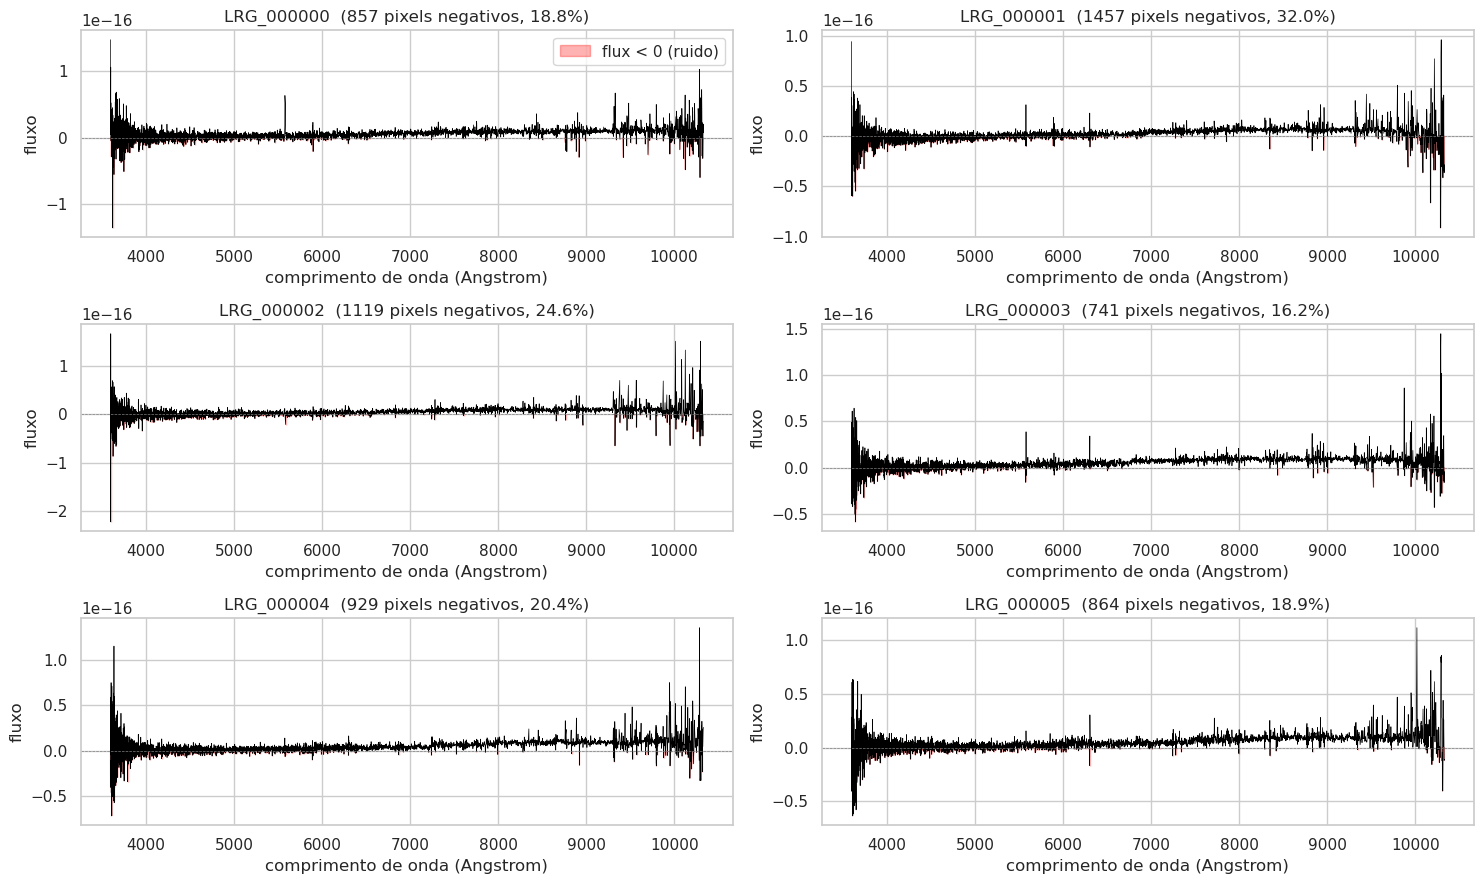

In [6]:
# ============================================================
# PLOT 2: 6 espectros com regioes negativas destacadas
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(15, 9))
axes = axes.ravel()

for i, (k, wave, flux) in enumerate(flux_examples):
    ax = axes[i]
    # Linha do espectro
    ax.plot(wave, flux, lw=0.5, color='black')
    # Marca regiao negativa em vermelho
    ax.fill_between(wave, flux, 0, where=(flux < 0), color='red', alpha=0.3, label='flux < 0 (ruido)')
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    n_neg = (flux < 0).sum()
    ax.set_title(f'{k}  ({n_neg} pixels negativos, {n_neg/len(flux)*100:.1f}%)')
    ax.set_xlabel('comprimento de onda (Angstrom)')
    ax.set_ylabel('fluxo')
    if i == 0:
        ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Interpretacao dos plots

Esperado:
- **A maioria dos espectros tem fluxo negativo em algumas regioes** (provavel: ~20-30%).
- **Regioes negativas tendem a estar em comprimentos de onda fracos** (azul extremo, vermelho extremo, ou em pixels com ceu forte).
- **Magnitudes pequenas**: o flux negativo nao desce muito abaixo de zero — e ruido em torno do zero, nao um sinal "reverso".

Se isso aparecer nos plots, **confirma que o negativo e fisica do detector, nao bug**.

## 4. E o `ivar`? Inverso da variancia confirma que e ruido?

Se o flux negativo for ruido, ele deve coincidir com regioes de **`ivar` baixo** (alta incerteza). Vou olhar.

In [ ]:
# ============================================================
# IVAR vs FLUXO — onde o ivar e baixo, esperamos flux ruidoso (talvez negativo)
# ============================================================
# ivar = 1 / sigma^2. Quanto maior, mais confiavel a medida.
# ivar baixo (~ 0) = pixel ruidoso (talvez mascarado por sky line).
#
# Hipotese: pixels com flux < 0 tem ivar baixo (medida ruim, ruido domina).

with h5py.File(ALL_H5, 'r') as h5:
    k = sorted(h5['spectra'].keys())[0]
    wave = h5[f'spectra/{k}/wave'][:]
    flux = h5[f'spectra/{k}/flux'][:]
    ivar = h5[f'spectra/{k}/ivar'][:]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(wave, flux, lw=0.5, color='black', label='flux')
axes[0].fill_between(wave, flux, 0, where=(flux < 0), color='red', alpha=0.3, label='flux < 0')
axes[0].axhline(0, color='gray', lw=0.5, ls='--')
axes[0].set_ylabel('fluxo')
axes[0].set_title(f'{k}: flux + regioes negativas')
axes[0].legend()

axes[1].plot(wave, ivar, lw=0.5, color='blue')
# Destaca pixels com ivar baixo (proxima de zero = ruidoso)
ivar_low_thresh = np.percentile(ivar[ivar > 0], 10)  # bottom 10% de ivar > 0
axes[1].fill_between(wave, 0, ivar.max()*1.05,
                     where=(ivar < ivar_low_thresh), color='orange', alpha=0.3,
                     label=f'ivar < q10 ({ivar_low_thresh:.2f})')
axes[1].set_ylabel('ivar = 1/sigma^2')
axes[1].set_xlabel('comprimento de onda (Angstrom)')
axes[1].set_title('ivar (alto = medida confiavel; baixo = pixel ruidoso)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Correlacao numerica: pixels com flux < 0 tem ivar tipicamente menor?
ivar_neg = ivar[flux < 0]
ivar_pos = ivar[flux > 0]
print(f'ivar mediano em pixels com flux < 0 : {np.median(ivar_neg):.3f}')
print(f'ivar mediano em pixels com flux > 0 : {np.median(ivar_pos):.3f}')
print(f'razao (neg/pos)                     : {np.median(ivar_neg)/np.median(ivar_pos):.2f}')
print(f'\nSe a razao for < 1, pixels negativos tem ivar menor -> sao mais ruidosos -> e ruido mesmo.')

## 5. Range completo apos normalize_spectra

Aplica a `normalize_spectra` que o notebook 07 usa, e confirma os limites.

In [ ]:
# Carrega via funcao do projeto (mesma forma do notebook 07)
X_orig, y, n_wave = load_spectral_dataset(PADDED_H5)
X_norm = normalize_spectra(X_orig).astype(np.float32)

print(f'X_orig shape : {X_orig.shape}')
print(f'X_orig range : [{X_orig.min():.3e}, {X_orig.max():.3e}]')
print(f'X_norm range : [{X_norm.min():.3f}, {X_norm.max():.3f}]')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma do bruto (so amostra pra nao explodir memoria)
sample_orig = X_orig[::100].ravel()
sample_orig = sample_orig[(sample_orig != 0)]  # tira padding
axes[0].hist(sample_orig, bins=200, color='steelblue', edgecolor='black', lw=0.2, log=True)
axes[0].axvline(0, color='red', ls='--', lw=1)
axes[0].set_xlabel('flux bruto')
axes[0].set_ylabel('# pixels (log)')
axes[0].set_title(f'Distribuicao do flux BRUTO (amostra, sem padding)')

# Histograma do normalizado
sample_norm = X_norm[::100].ravel()
sample_norm = sample_norm[sample_norm != 0]
axes[1].hist(sample_norm, bins=200, color='coral', edgecolor='black', lw=0.2, log=True)
axes[1].axvline(0, color='red', ls='--', lw=1)
axes[1].axvline(-1, color='black', ls=':', lw=1)
axes[1].axvline(+1, color='black', ls=':', lw=1)
axes[1].set_xlabel('flux normalizado (max-abs)')
axes[1].set_ylabel('# pixels (log)')
axes[1].set_title('Distribuicao apos normalize_spectra (em [-1, +1])')

plt.tight_layout()
plt.show()

## 6. Conclusao

Preencha abaixo com base nos numeros que sairam:

**Pergunta 1: flux negativo e real?**
- [ ] Sim, ~__% dos pixels tem flux < 0 (varia por espectro)
- [ ] As regioes negativas coincidem com ivar baixo (ruido confirmado)
- [ ] Magnitude pequena (proximo de zero, nao "reverso")

**Pergunta 2: por que padded e menor?**
- [ ] all = 167k espectros, padded = 131k (perdeu ~22% no filtro de qualidade)
- [ ] all guarda flux + ivar + wave por espectro; padded so flux + wave_global
- [ ] gzip num bloco 2D grande comprime melhor